# Covasim for wastewater step by step tutorial
1. In order to run the following code, first we need to make sure covasim and its dependecies are installed.
Please follow the instructions here https://github.com/andersen-lab/covasim4wastewater to install.
(Full covasim tutorial available at : https://docs.covasim.org/tutorials/)
2. To start, we will run a basic simulation as following. We start with creating a simulation object that simulates an outbreak in Zambia, with a population size of 60 people, 3 initial infections for 50 days. The contact network between individuals is assigned as "hybrid" meaning that people interact with each other at workplaces, schools, households and also randomly. There are no cases imported daily cases.

In [ ]:
import covasim as cv
import numpy as np
import matplotlib.pyplot as plt

sim = cv.Sim(
    pop_size=100000,
    pop_type='hybrid',
    pop_infected=3,
    location='zambia',
    n_days=100,
    n_imports=0
)
sim.run()

Warning, could not install some fonts:
[Errno 2] No such file or directory: '/storage/mahmadi/mambaforge/envs/covasim/lib/python3.10/site-packages/covasim/data/assets'
Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM
Initializing sim with 100000 people for 100 days
Loading location-specific data for "zambia"
Downloading: https://data.worldpop.org/GIS/Population/Global_2000_2020/2020/ZMB/zmb_ppp_2020.tif
403.7 / 403.7 MB
Downloading: https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_ZMB.gpkg
5.1 / 5.1 MB
  Running 2020-03-01 ( 0/100) (457.23 s)  ———————————————————— 1%
  Running 2020-03-11 (10/100) (457.42 s)  ••—————————————————— 11%
  Running 2020-03-21 (20/100) (457.59 s)  ••••———————————————— 21%
  Running 2020-03-31 (30/100) (457.64 s)  ••••••—————————————— 31%
  Running 2020-04-10 (40/100) (457.70 s)  ••••••••———————————— 41%
  Running 2020-04-20 (50/100) (457.76 s)  ••••••••••—————————— 50%
  Running 2020-04-30 (60/100) (457.81 s)  ••••••••••••———————— 60%
  Running 2020-05-10 

Sim(<no label>; 2020-03-01 to 2020-06-09; pop: 100000 hybrid; epi: 5⚙, 0☠)

## Wastewater viral loads

To estimate how much each infected individual is shedding to wastewater,
 we use the shedding hub https://shedding-hub.github.io, "woelfel2020virological" dataset.

For each individual, the full `pop_size × n_days` viral load history matrix is stored in `sim.results['viral_load_hist']`.
The following plot shows how much each agent in the simulation is shedding (Cell color) throughout the entire simulation. (x axis time- y axis agent)

/tmp/ipykernel_519722/2733213321.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


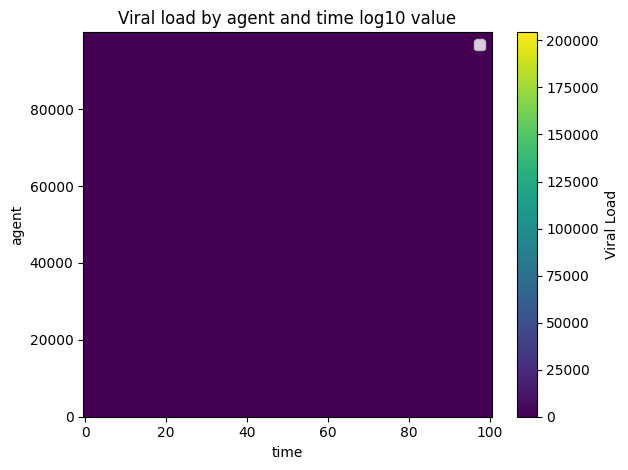

In [6]:
viral_shedding = sim.results['viral_shedding_hist']
im = plt.imshow(
viral_shedding,
aspect='auto', # prevents squashing
origin='lower', # agent 0 at bottom
cmap='viridis' # choose colormap
)

plt.colorbar(im, label='Viral Load')

plt.xlabel('time')
plt.ylabel('agent')
plt.title('Viral load by agent and time log10 value')
plt.legend()
plt.tight_layout()

We then look at the overall shedding (total for all agents) and region-specific shedding at each time point. Here, we pull the population data for Zambia and assign people to each region based on the population density in the regions.

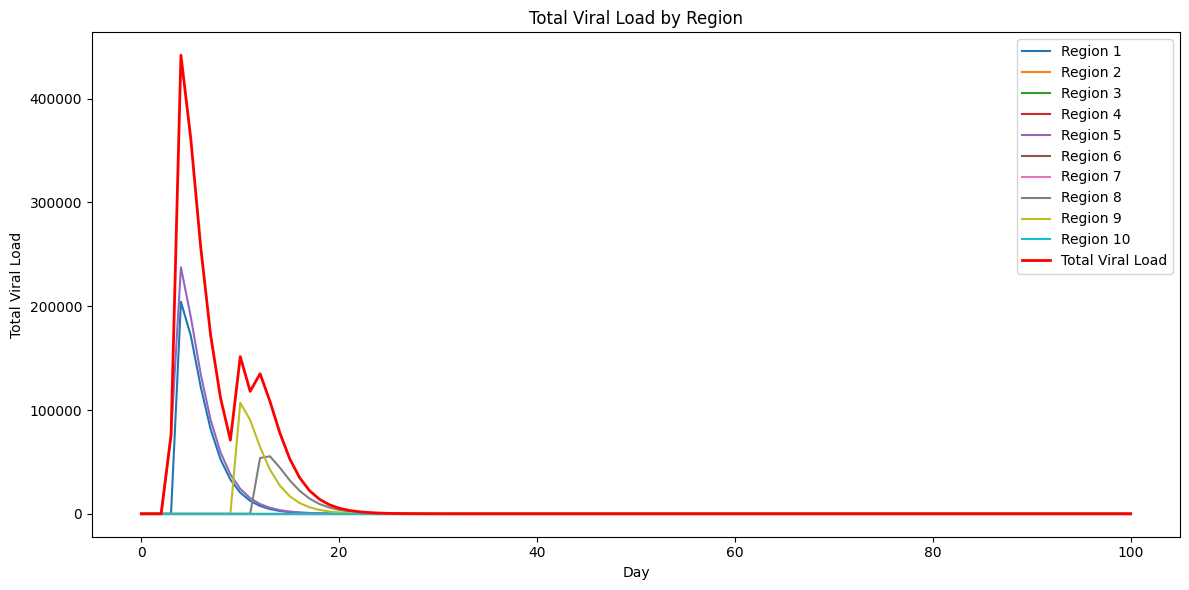

In [7]:
regions = np.asarray(sim.people.region)
sum_vl = viral_shedding.sum(axis=0)
unique_regions = np.unique(regions)
plt.figure(figsize=(12, 6))
for region in unique_regions:
    mask = regions == region
    regional_load = viral_shedding[mask].sum(axis=0)
    plt.plot(regional_load, label=f'Region {region}')
# Population total
plt.plot(
    sum_vl,
    linewidth=2,
    color='red',
    label='Total Viral Load'
)
plt.xlabel('Day')
plt.ylabel('Total Viral Load')
plt.title('Total Viral Load by Region')
plt.legend()
plt.tight_layout()
plt.show()

The total cumulative viral shedding in each region can also be shown on the Zambia's map as follows:

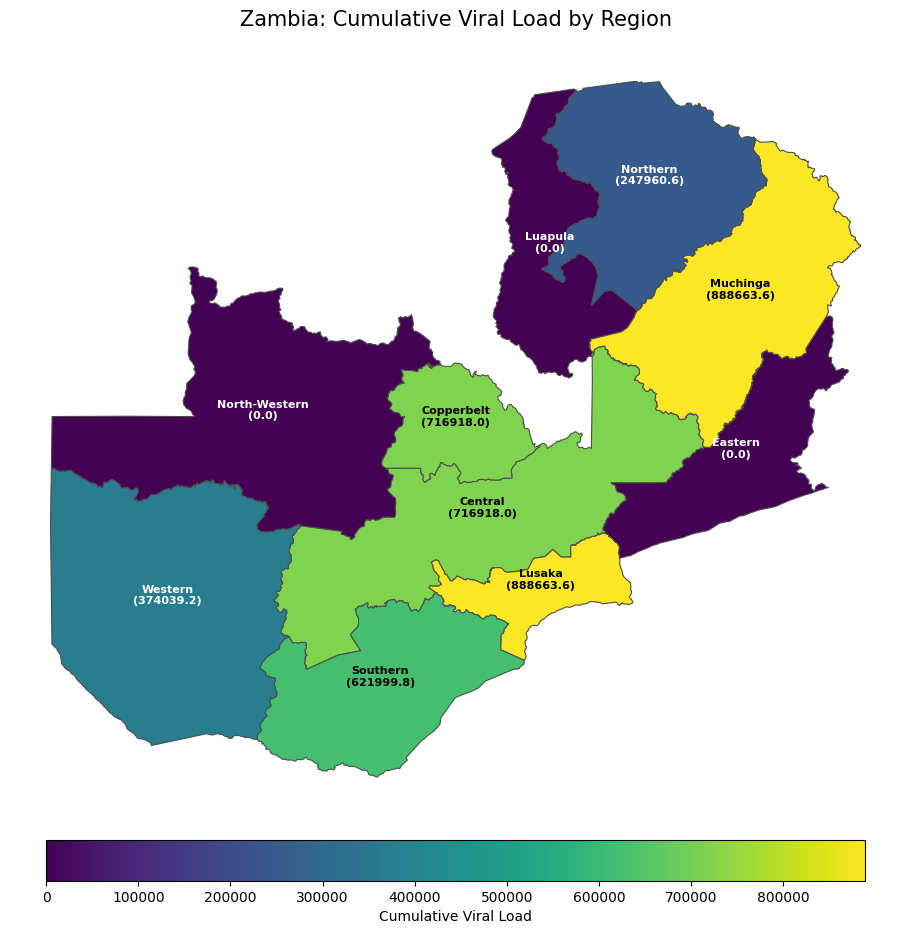

In [ ]:
import pandas as pd
import os
import geopandas as gpd

pop_df = pd.read_csv('population_data.csv')

# ---------------------------------------------------------
# 2. Calculate Total Cumulative Viral Load per Region
# ---------------------------------------------------------
regions = np.asarray(sim.people.region)
viral_shedding = sim.results['viral_shedding_hist']  # Shape: (n_people, n_days)

# Sum across time for each agent to get total individual viral load
agent_total_load = viral_shedding.sum(axis=1)

# Calculate cumulative load per region code
region_loads = {}
for code in pop_df['region_code']:
    mask = (regions == code) | (regions == (code - 1))  # Handles 0-indexed or 1-indexed region mapping
    region_loads[code] = float(agent_total_load[mask].sum())

pop_df['total_viral_load'] = pop_df['region_code'].map(region_loads)

# ---------------------------------------------------------
# 3. Load Zambia Boundary Shapefile (GADM Level 1)
# ---------------------------------------------------------
gadm_path = os.path.join("raster_cache", "gadm41_ZMB.gpkg")

if os.path.exists(gadm_path):
    zambia_gdf = gpd.read_file(gadm_path, layer="ADM_ADM_1")
else:
    # Download GADM v4.1 Level 1 directly if local cache file is absent
    url = "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_ZMB.gpkg"
    zambia_gdf = gpd.read_file(url, layer="ADM_ADM_1")

# Match GADM region names to population data region names
# Align spatial GeoDataFrame with pop_df ordering
zambia_gdf = zambia_gdf.merge(
    pop_df, 
    left_on="NAME_1", 
    right_on="region_name", 
    how="left"
)

# Fallback: If merge key differs on exact string spelling, assign by index order
if zambia_gdf['total_viral_load'].isna().any():
    zambia_gdf['total_viral_load'] = pop_df['total_viral_load'].values
    zambia_gdf['region_name'] = pop_df['region_name'].values

# ---------------------------------------------------------
# 4. Plot Choropleth Map of Zambia Shaded by Viral Load
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot map layer
zambia_gdf.plot(
    column='total_viral_load',
    cmap='viridis',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.3',
    legend=True,
    legend_kwds={
        'label': "Cumulative Viral Load",
        'orientation': "horizontal",
        'shrink': 0.7,
        'pad': 0.03
    }
)

# Add region text labels on centroids
for idx, row in zambia_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=f"{row['region_name']}\n({row['total_viral_load']:.1f})",
        xy=(centroid.x, centroid.y),
        horizontalalignment='center',
        fontsize=8,
        fontweight='bold',
        color='black' if row['total_viral_load'] > zambia_gdf['total_viral_load'].mean() else 'white'
    )

ax.set_title('Zambia: Cumulative Viral Load by Region', fontsize=15, pad=15)
ax.set_axis_off()

plt.tight_layout()
plt.show()

## Genomic simulation
In this section, we use Covasim to simulate how different SARS-CoV-2 variants—specifically **wild-type, AY.4, BA.2, and XBB.1.5**—spread over time. We track these variants using consensus FASTA files and plot their infectious counts on both absolute and proportional scales.

### How it works

* **Seeding variants:** We introduce each new variant using a `founding_fasta` file, which defines its specific mutation profile when it enters the population.
* **Tracking infections:** To track variant proportions over time, we pull daily counts directly from `sim.results['variant']['n_infectious_by_variant']`—Covasim's built-in tracker for daily infectious cases per variant.
* **Wastewater sampling:** The `WastewaterSampler` tool isn't needed to plot these infection numbers; it's used only to generate the haplotype-resolved data required for Bygul (covered in the next section).

> **Note:** Make sure to run this notebook from the `docs/tutorials/` directory so Covasim can find the FASTA files located in `sars-2-data/variants/`.


In [10]:


# Paths are relative to docs/tutorials/ — run the notebook from that directory.
ref_fasta         = 'sars-2-data/NC_045512_Hu-1.fasta'
fitness_data_path = '../../data/nt_fitness.csv'
ay4_fasta         = 'sars-2-data/variants/AY.4_consensus.fasta'
ba2_fasta         = 'sars-2-data/variants/BA.2.9_consensus.fasta'
xbb15_fasta       = 'sars-2-data/variants/XBB.1.5.18_consensus.fasta'
artic_primers     = 'sars-2-data/ARTIC_V4-1.bed'

# Variants — rel_beta is NOT hard-coded.  evo_pars (below) derives the
# transmission advantage from each variant's founding mutations by looking up
# every SNP in the Bloom lab nucleotide fitness landscape and computing
# rel_beta = exp(Σ log_fitness_i × fitness_scale).
ay4 = cv.variant(
    label          = 'AY.4',
    days           = 30, # introduce AY.4 on day 30
    n_imports      = 50,
    founding_fasta = ay4_fasta,
)
ba2 = cv.variant(
    label          = 'BA.2',
    days           = 60, # introduce BA.2 on day 60
    n_imports      = 50,
    founding_fasta = ba2_fasta,
)
xbb15 = cv.variant(
    label          = 'XBB.1.5',
    days           = 100, # introduce XBB.1.5 on day 100
    n_imports      = 50,
    founding_fasta = xbb15_fasta, # the variant's sequence when first introduced
)

# WastewaterSampler captures each unique evolved haplotype so simulate_sample()
# can feed the mixture to Bygul for amplicon-read synthesis.
# Sampled after XBB.1.5's introduction (day 100) while all four variants are
# likely still co-circulating.
_haplotype_days = list(range(110, 151, 5))   # days 110, 115, 120 … 150
ww = cv.WastewaterSampler(
    days  = _haplotype_days,
    label = 'WastewaterHaplotype',
)

sim = cv.Sim(
    dict(
        pop_size     = 20_000,
        pop_infected = 20, #initial infections
        start_day    = '2022-10-01',
        end_day      = '2023-04-01',
        evo_pars = dict( #evolutionary parameters for the simulation
            enable            = True,
            reference         = ref_fasta,
            mol_clock_rate    = 1e-6,
            fitness_model     = 'bloom_nt',           # Bloom lab nt_fitness.csv https://github.com/jbloomlab/SARS2-mut-fitness
            fitness_data_path = fitness_data_path,
            fitness_scale     = 0.05,                 # multiplies log-fitness sum before exp()
        ),
    ),
    variants  = [ay4, ba2, xbb15],
    analyzers = [ww],
    verbose   = 0,
)
sim.run()

Sim(<no label>; 2022-10-01 to 2023-04-01; pop: 20000 random; epi: 58230⚙, 189☠)

Read more about sequence evolution : https://github.com/andersen-lab/covasim4wastewater/blob/main/docs/tutorials/tut_sequence_evol.ipynb
The following code calculates the relative beta for each variant and shows the SNP counts compared to the founding sequence.

In [11]:
# Show the rel_beta multiplier that was derived from each variant's founding mutations.
# This makes the FASTA → fitness → transmissibility pathway explicit.
tracker       = sim.people.sequence_tracker
fitness_model = tracker.fitness_model

print(f'{"variant":12s}  {"founding SNPs":>13s}  {"rel_beta (×wt)":>15s}')
print('-' * 46)
# Wild-type carries no founding mutations → reference fitness = 1.0
for label, muts in [('wild', frozenset())] + list(tracker.variant_founding_mutations.items()):
    mult = fitness_model.compute_fitness(muts)
    print(f'{label:12s}  {len(muts):>13d}  {mult:>15.4f}')

variant       founding SNPs   rel_beta (×wt)
----------------------------------------------
wild                      0           1.0000
AY.4                     43           1.7579
BA.2                     60           5.0353
XBB.1.5                  81          11.1664


The following code generates plots that show variant specific case counts at each time point. We can also see the prportions of infected people by each variant. The plot shows how each specific variant takes over based on the day they are introduced. e.g. 'AY.4': 30, 'BA.2': 60, 'XBB.1.5': 100 (dashed lines)

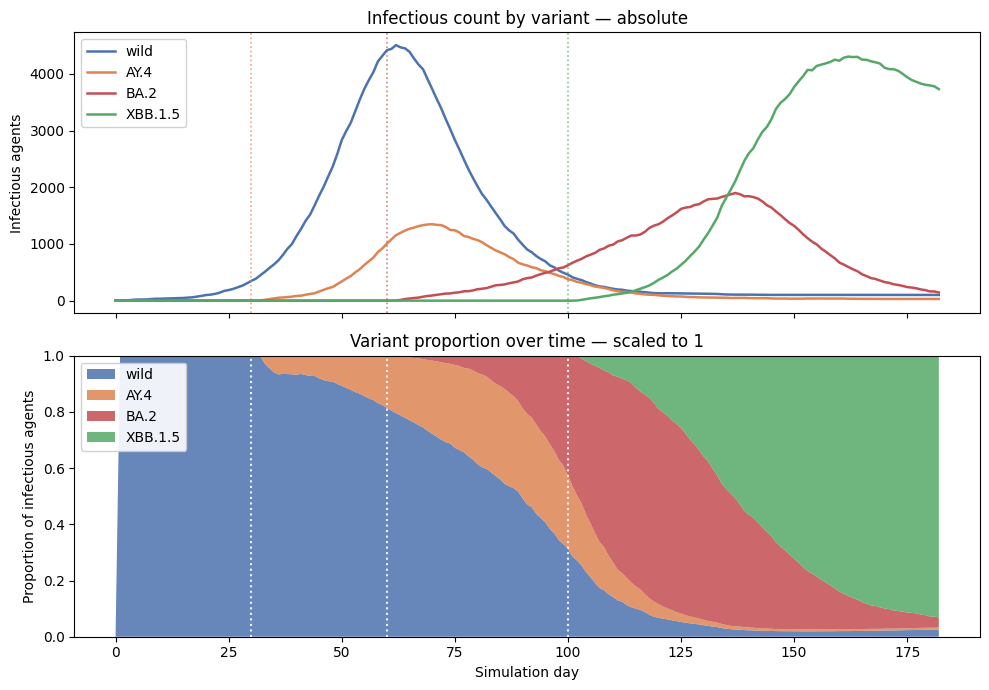

In [12]:
variant_names = list(sim['variant_map'].values())   # e.g. ['wild', 'AY.4', 'BA.2', 'XBB.1.5']
n_steps = sim.npts

# Per-variant infectious counts from the standard Covasim result.
# Shape: (n_variants, n_steps).
n_inf = np.array(sim.results['variant']['n_infectious_by_variant'].values)
total = n_inf.sum(axis=0)
total[total == 0] = 1  # avoid division by zero on days with no infections

loads = {v: n_inf[i] for i, v in enumerate(variant_names)}
props = {v: n_inf[i] / total for i, v in enumerate(variant_names)}

# Color palette (extend automatically for any extra variants)
palette = {'wild': '#4C72B0', 'AY.4': '#DD8452', 'BA.2': '#C44E52', 'XBB.1.5': '#55A868'}
_defaults = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, v in enumerate(variant_names):
    palette.setdefault(v, _defaults[i % len(_defaults)])

tvec       = np.arange(n_steps)
intro_days = {'AY.4': 30, 'BA.2': 60, 'XBB.1.5': 100}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# -- Absolute infectious counts -----------------------------------------------
for vname in variant_names:
    ax1.plot(tvec, loads[vname], label=vname, color=palette[vname], linewidth=1.8)
for vname, day in intro_days.items():
    ax1.axvline(day, color=palette[vname], linestyle=':', linewidth=1.2, alpha=0.7)
ax1.set_ylabel('Infectious agents')
ax1.set_title('Infectious count by variant — absolute')
ax1.legend(framealpha=0.9)

# -- Scaled to 1 (stacked area) -----------------------------------------------
stacked = np.array([props[v] for v in variant_names])
ax2.stackplot(tvec, stacked,
              labels=variant_names,
              colors=[palette[v] for v in variant_names],
              alpha=0.85)
for vname, day in intro_days.items():
    ax2.axvline(day, color='white', linestyle=':', linewidth=1.5, alpha=0.9)
ax2.set_xlabel('Simulation day')
ax2.set_ylabel('Proportion of infectious agents')
ax2.set_title('Variant proportion over time — scaled to 1')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

## Amplicon sequencing snapshot with Bygul

`WastewaterSampler` records every unique evolved haplotype present in the
infectious pool on each sampling day.  At a time-point where wild-type, AY.4,
BA.2, and XBB.1.5 all co-circulate the mixture mirrors what a real wastewater
sequencing lab would see.

`simulate_sample()` writes each haplotype to a temporary FASTA file and calls
[Bygul](https://github.com/andersen-lab/Bygul)'s `simulate_proportions` CLI,
which tiles ARTIC V4.1 amplicons across each genome and produces synthetic
paired-end reads at the observed mixture proportions — giving a realistic
amplicon-sequencing dataset that reflects the simulated epidemiology.

> **Requires** the `bygul` package: `pip install bygul`  (installing through conda is recommended conda install bioconda::bygul)
> BED file and reference FASTA are read from `sars-2-data/` via the paths
> set in the earlier cell (`artic_primers`, `ref_fasta`).

In [13]:
import glob, os, dataclasses

# From the candidate haplotype days, pick the first where all four variants
# each hold >1% of signal.  Fall back to day 120 if none qualifies.
ww = sim.get_analyzer('WastewaterHaplotype')
mixed_day = next(
    (t for t in sorted(ww.samples)
     if ww.samples[t] is not None
     and all(props[v][t] > 0.01 for v in ['wild', 'AY.4', 'BA.2', 'XBB.1.5'])),
    120,
)

print(f'Sampling day {mixed_day}  ({sim.date(mixed_day)})')
print('  Variant-level proportions at that day:')
for v in ['wild', 'AY.4', 'BA.2', 'XBB.1.5']:
    print(f'    {v:10s}  {props[v][mixed_day]:.1%}')

sample = ww.samples.get(mixed_day)
if sample is None:
    print('\nNo infectious agents were present on that day.')
else:
    print(f'\n  Unique haplotypes in pool : {sample.n_genotypes}')

    # Rank haplotypes by proportion and keep the top 5.
    # Renormalize so the subset proportions still sum to 1.0 — Bygul requires this.
    order     = sorted(range(sample.n_genotypes),
                       key=lambda i: sample.proportions[i], reverse=True)[:5]
    top_seqs  = [sample.mutation_sets[i]   for i in order]
    top_loads = [sample.raw_loads[i]   for i in order]
    top_props = [sample.proportions[i] for i in order]
    top_total = sum(top_props)
    top_props = [p / top_total for p in top_props]
    top_props[-1] = 1.0 - sum(top_props[:-1])   # absorb floating-point residual

    print(f'  Top-5 proportions (renormalized): {[round(p, 4) for p in top_props]}')
    print(f'  These cover {top_total:.1%} of the full pool by viral shedding')

    # Replace the stored sample with the trimmed version so simulate_sample() sees it
    ww.samples[mixed_day] = dataclasses.replace(
        sample,
        mutation_sets = top_seqs,
        proportions   = top_props,
        raw_loads       = top_loads,
        n_genotypes     = len(top_seqs),
    )

# artic_primers and ref_fasta were set in the earlier cell
outdir = './amplicon_reads/'

try:
    ww.simulate_sample(
        day             = mixed_day,
        primers         = artic_primers,
        reference       = ref_fasta,
        outdir          = outdir,
        readcnt         = 300,
        redo            = True,
        simulation_mode = 'amplicon',
        seed            = 42,
    )
    fastq_files = (
        glob.glob(os.path.join(outdir, '**/*.fastq*'), recursive=True) +
        glob.glob(os.path.join(outdir, '*.fastq*'))
    )
    print(f'\nBygul wrote {len(fastq_files)} FASTQ file(s) to {outdir!r}:')
    for f in sorted(set(fastq_files))[:12]:
        print(f'  {os.path.relpath(f)}  ({os.path.getsize(f)/1024:.1f} kB)')
except ImportError as exc:
    print('\n[Bygul not installed — skipping read simulation]')
    print(str(exc))
    print('Install: pip install bygul   (https://github.com/andersen-lab/Bygul)')


Sampling day 110  (2023-01-19)
  Variant-level proportions at that day:
    wild        14.1%
    AY.4        12.3%
    BA.2        66.5%
    XBB.1.5     7.1%

  Unique haplotypes in pool : 415
  Top-5 proportions (renormalized): [0.5785, 0.2139, 0.1083, 0.0556, 0.0437]
  These cover 40.5% of the full pool by viral shedding
Reading and preprocessing the primer file...
Spinning up parallel execution for 5 samples...


Simulation progress...:   0%|          | 0/5 [00:00<?, ?it/s]


Genome: genotype_0
Genome: genotype_1
Genome: genotype_2
Genome: genotype_3
Genome: genotype_4



  Total ambiguous bases: 0
  Total ambiguous bases: 0  Total ambiguous bases: 0
  Total ambiguous bases: 0  Total ambiguous bases: 0

  Contig lengths:  Contig lengths:
  Contig lengths:


  Contig lengths:
    genotype_1: 29903
  Contig lengths:    genotype_2: 29903    genotype_3: 29903
    genotype_4: 29903



    genotype_0: 29903
No valid sequences for amplicon 75,no file written.please checkout the amplicon_stats.csv file for more information.
No valid sequences for amplicon 75,no file written.please checkout the amplicon_stats.csv file for more information.
No valid sequences for amplicon 75,no file written.please checkout the amplicon_stats.csv file for more information.No valid sequences for amplicon 75,no file written.please checkout the amplicon_stats.csv file for more information.



Simulation progress...: 100%|██████████| 5/5 [00:01<00:00,  4.36it/s]


Merging reads for genotype_3...

Merging reads for genotype_4...

Merging reads for genotype_1...

Merging reads for genotype_2...

Merging reads for genotype_0...


Finished all samples!

Bygul wrote 1130 FASTQ file(s) to './amplicon_reads/':
  amplicon_reads/genotype_0/reads/amplicon_10_contig1_1.fastq  (13.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig1_2.fastq  (13.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig2_1.fastq  (13.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig2_2.fastq  (13.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig3_1.fastq  (13.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig3_2.fastq  (13.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig4_1.fastq  (13.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_10_contig4_2.fastq  (13.0 kB)
  amplicon_reads/genotype_0/reads/amplicon_11_contig1_1.fastq  (51.6 kB)
  amplicon_reads/genotype_0/reads/amplicon_11_contig1_2.fastq  (51.6 kB)
  amplicon_reads/genotype_0/reads/amplicon_12_contig1_1.fastq  (51.6 kB)
  amplicon_reads/genotype_0/reads/amplicon_12_contig1_2.fastq  (51.6 kB)
